# Notebook 08 — ProtoNet (Prototypical Networks)

**Method:** Snell et al., *Prototypical Networks for Few-Shot Learning*, NeurIPS 2017  
**HAR domain reference:** Zheng et al., *Meta-learning meets IoT*, 2021

**Core idea:**  
Learn an embedding space where each activity class is represented  
by the mean of its support embeddings (the prototype).  
Classify query samples by nearest prototype using Euclidean distance.

**Pipeline:**
```
Pre-trained backbone
    ↓
Episodic meta-training (N-way K-shot episodes on train users)
    ↓
Evaluation:
  A) Generalization  — test users, no adaptation, nearest prototype
  B) Personalization — K examples from test user → prototypes → classify rest
    ↓
Personalization gain = acc_after − acc_before
```

**This notebook:**
- Runs on one dataset × one backbone at a time
- Set `DATASET_NAME` and `BACKBONE_TYPE` in Cell 1
- For Phase 1: `DATASET_NAME='wisdm'`, `BACKBONE_TYPE='cnn'`
- Phase 3: repeat for `'lstm'` and `'transformer'`
- Phase 4: repeat for other datasets

---
**Requires:** notebook 00, preprocessing notebook for chosen dataset,  
and the corresponding backbone checkpoint from notebooks 05/06/07.

**Justification - ProtoNet Learning Rate Penalty:** During the episodic training phase of ProtoNet, the global learning rate was reduced by a factor of 3 (from 3e-4 to 1e-4). Because the backbone is initialized with pre-trained weights that already generate a highly separated latent space, a lower learning rate is critical. It prevents the network from aggressively destroying the pre-trained embedding structure, encouraging smooth clustering around class prototypes. Also, a StepLR scheduler was used to halve the learning rate every 20 epochs to finely tune the embedding space.

## Cell 1 — Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

%run "/content/drive/MyDrive/Colab Notebooks/00_config_and_utils.ipynb"
# ─── Configuration ────────────────────────────────────────────────────────────
# Phase 1 : DATASET_NAME='wisdm',  BACKBONE_TYPE='cnn'
# Phase 3 : BACKBONE_TYPE='lstm' or 'transformer'
# Phase 4 : DATASET_NAME='cogage_atomic' / 'cogage_composite' / 'humcare'
DATASET_NAME   = 'wisdm'
BACKBONE_TYPE  = 'cnn'    # 'cnn' | 'lstm' | 'transformer'

# Distance metric for prototype matching
DISTANCE_METRIC = 'euclidean'   # 'euclidean' | 'cosine'

print(f'\n✅ Setup complete')
print(f'   Method   : ProtoNet')
print(f'   Dataset  : {DATASET_NAME}')
print(f'   Backbone : {BACKBONE_TYPE}')
print(f'   Distance : {DISTANCE_METRIC}')
print(f'   Device   : {DEVICE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results         → /content/drive/MyDrive/fsl_har_results
✅ Dataset configs loaded
   wisdm                  →  51 subjects |  18 classes |  4 streams | n_way=5
   cogage_atomic          →   8 subje

## Cell 2 — Load Dataset and Backbone

✅ Loaded "wisdm" — 63513 windows | 4 streams
── Dataset: wisdm ──
   Windows  : 63,513  |  streams: 4  |  classes: 18
   n_way    : 5
   Train    : 47,037  |  Val: 7,596  |  Test: 8,880
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK
   PyTorch  : 2.10.0+cu128
   NumPy    : 2.0.2
   CUDA     : True
   GPU      : Tesla T4
✅ Seeded everything with MASTER_SEED=42
✅ Global hyperparameters set
   Target frequency : 50 Hz
   Window size      : 250 samples (5.0 sec)
   Window stride    : 125 samples (2.5 sec)
   K shots          : [1, 5, 10]
   N way (default)  : 5
   Embedding dim    : 128
   Device           : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Paths configured
   Processed data  → /content/drive/MyDrive/fsl_har_processed
   Checkpoints     → /content/drive/MyDrive/fsl_har_checkpoints
   Results    

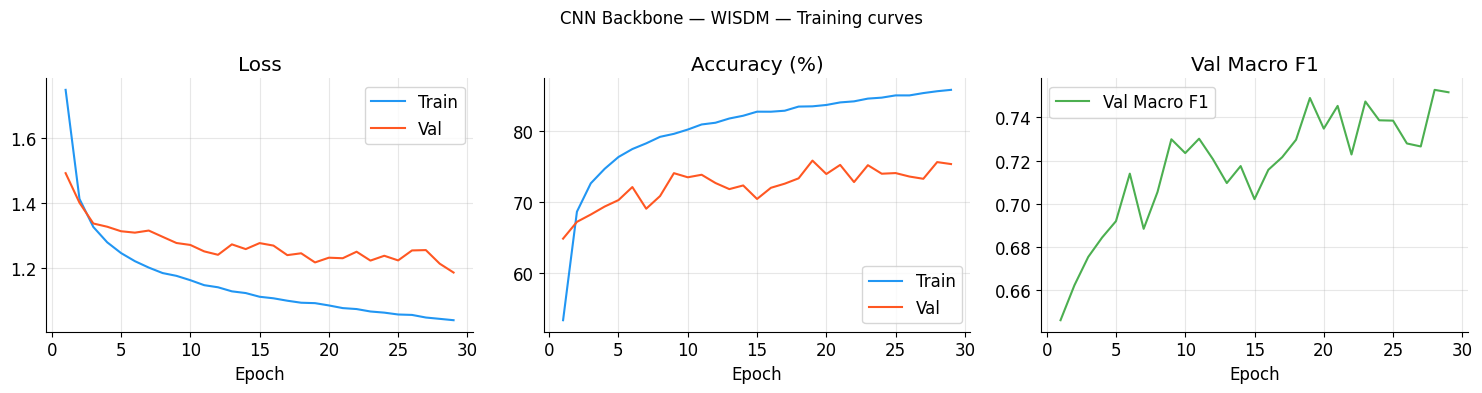

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/training_curves.png
Loaded checkpoint from epoch 19
  Checkpoint val acc : 75.78%

── Test set results (unseen users, no adaptation) ──
   Test accuracy  : 69.11%
   Test macro F1  : 0.6766
   Test loss      : 1.3872

   This is the GENERALIZATION baseline.
   FSL methods will improve on this through personalization.

✅ Result saved to registry


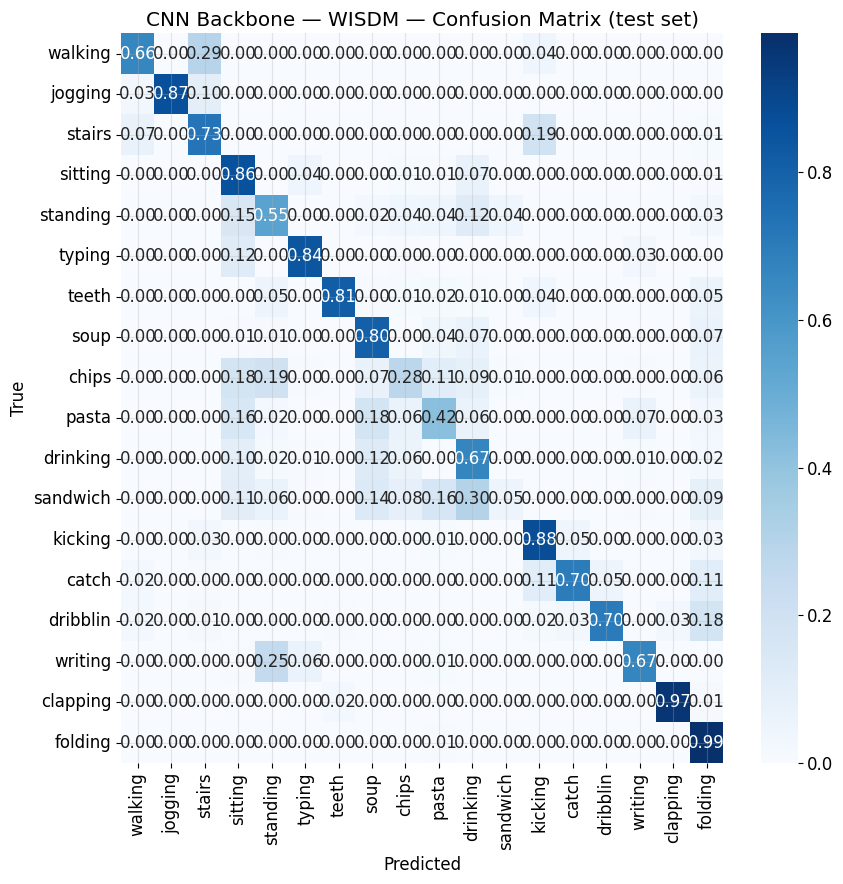

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/confusion_matrix.png
Verifying backbone interface for FSL methods...

   n_way=5, k_shot=5
   Support batch size : 25
   Support embeddings : torch.Size([25, 128])
   Expected           : (25, 128)
   Embedding norms    : mean=7.486, std=0.260

✅ Backbone interface verified
   FSL methods can load this backbone with:
   backbone = CNNBackbone(n_streams=4, n_classes=18, ...)
   load_checkpoint(backbone, '/content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_backbone.pt')
   embeddings = backbone.get_embedding(stream_list)
  CNN BACKBONE TRAINING COMPLETE
  Dataset          : wisdm
  Streams          : 4  (['phone_accel', 'phone_gyro', 'watch_accel', 'watch_gyro'])
  Classes          : 18
  Embedding dim    : 128
  Epochs trained   : 29
  Best val acc     : 75.78%
  Test acc         : 69.11%  ← generalization baseline
  Test macro F1    : 0.6766
  Checkpoint       : /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/best_b

In [ ]:
# ─── Load dataset ─────────────────────────────────────────────────────────────
data = load_processed_dataset(DATASET_NAME)

streams      = data['streams']
y            = data['y']
subject_ids  = data['subject_ids']
stream_names = data['stream_names']
split_info   = data['split_info']
cfg          = data['config']
sam          = data.get('subject_activity_map')   # Humcare only

n_streams  = len(stream_names)
n_classes  = cfg['n_classes']
n_way      = cfg['n_way']
N, T, C    = streams[stream_names[0]].shape

# Force both sides to strings for bulletproof matching
sub_ids_str = subject_ids.astype(str)
train_split = [str(s) for s in split_info['train']]
val_split   = [str(s) for s in split_info['val']]
test_split  = [str(s) for s in split_info['test']]

# Build subject masks
train_mask = get_split_mask(sub_ids_str, train_split)
val_mask   = get_split_mask(sub_ids_str, val_split)
test_mask  = get_split_mask(sub_ids_str, test_split)

print(f'── Dataset: {DATASET_NAME} ──')
print(f'   Windows  : {N:,}  |  streams: {n_streams}  |  classes: {n_classes}')
print(f'   n_way    : {n_way}')
print(f'   Train    : {train_mask.sum():,}  |  Val: {val_mask.sum():,}  |  Test: {test_mask.sum():,}')

# ─── Load backbone ────────────────────────────────────────────────────────────
ckpt_path = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'best_backbone.pt')
assert os.path.exists(ckpt_path), (
    f'Backbone checkpoint not found: {ckpt_path}\n'
    f'Run notebook 0{ {"cnn":"5", "lstm":"6", "transformer":"7"}[BACKBONE_TYPE] } first.'
)

# Import backbone class from the appropriate notebook
# The backbone class definitions live in notebooks 05/06/07
# We load them via %run — use only one
if BACKBONE_TYPE == 'cnn':
    %run "/content/drive/MyDrive/Colab Notebooks/05_train_backbone_cnn.ipynb"
    BackboneClass = CNNBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_stream=64, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'lstm':
    %run "/content/drive/MyDrive/Colab Notebooks/06_train_backbone_lstm.ipynb"
    BackboneClass = LSTMBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           input_size=C, hidden_size=64, num_layers=2,
                           dropout=0.3, embedding_dim=EMBEDDING_DIM)
elif BACKBONE_TYPE == 'transformer':
    %run "/content/drive/MyDrive/Colab Notebooks/07_train_backbone_transformer.ipynb"
    BackboneClass = TransformerBackbone
    backbone_kwargs = dict(n_streams=n_streams, n_classes=n_classes,
                           in_channels=C, d_model=64, nhead=4, num_layers=2,
                           dim_feedforward=256, dropout=0.1, embedding_dim=EMBEDDING_DIM)

backbone = BackboneClass(**backbone_kwargs).to(DEVICE)
meta = load_checkpoint(backbone, ckpt_path)
print(f'\n── Backbone: {BACKBONE_TYPE} ──')
print(f'   Loaded from  : {ckpt_path}')
print(f'   Trained epoch: {meta.get("epoch", "?")}')
print(f'   Pretrain acc : {meta.get("val_acc", 0)*100:.2f}%')
n_params = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
print(f'   Parameters   : {n_params:,}')

## Cell 3 — ProtoNet Core

The two key operations:
1. `compute_prototypes` — mean of support embeddings per class
2. `prototypical_loss` — cross-entropy over negative squared distances

In [ ]:
def compute_prototypes(
    support_embeddings : torch.Tensor,
    support_labels     : torch.Tensor,
    n_way              : int,
) -> torch.Tensor:
    """
    Safe prototype computation (handles missing classes).
    """
    embedding_dim = support_embeddings.shape[-1]
    device        = support_embeddings.device

    prototypes = torch.zeros(n_way, embedding_dim, device=device)

    for c in range(n_way):
        mask = (support_labels == c)

        if mask.sum() == 0:
            # 🚨 Critical fix: skip empty class instead of NaN
            continue

        prototypes[c] = support_embeddings[mask].mean(dim=0)

    return prototypes


def pairwise_distances(
    queries    : torch.Tensor,
    prototypes : torch.Tensor,
    metric     : str = 'euclidean',
) -> torch.Tensor:

    if prototypes.size(0) == 0:
        # 🚨 Prevent crash
        return torch.empty(queries.size(0), 0, device=queries.device)

    if metric == 'euclidean':
        q_sq = (queries ** 2).sum(dim=-1, keepdim=True)
        p_sq = (prototypes ** 2).sum(dim=-1, keepdim=True).T
        dot  = queries @ prototypes.T
        return q_sq + p_sq - 2 * dot

    elif metric == 'cosine':
        q_norm = nn.functional.normalize(queries, dim=-1)
        p_norm = nn.functional.normalize(prototypes, dim=-1)
        return 1.0 - (q_norm @ p_norm.T)

    else:
        raise ValueError(f'Unknown metric: {metric}')


def prototypical_loss(
    query_embeddings : torch.Tensor,
    query_labels     : torch.Tensor,
    prototypes       : torch.Tensor,
    metric           : str = 'euclidean',
) -> Tuple[torch.Tensor, float]:

    # 🚨 HARD GUARD (prevents your exact crash)
    if prototypes.size(0) == 0 or query_embeddings.size(0) == 0:
        return torch.tensor(0.0, device=query_embeddings.device), 0.0

    distances = pairwise_distances(query_embeddings, prototypes, metric)

    # 🚨 Another guard
    if distances.size(-1) == 0:
        return torch.tensor(0.0, device=query_embeddings.device), 0.0

    log_probs = nn.functional.log_softmax(-distances, dim=-1)
    loss      = nn.functional.nll_loss(log_probs, query_labels)

    preds    = distances.argmin(dim=-1)
    accuracy = (preds == query_labels).float().mean().item()

    return loss, accuracy


print('✅ ProtoNet core functions (SAFE) loaded')

✅ ProtoNet core functions (SAFE) loaded


## Cell 4 — Episode Sampler Setup

In [ ]:
# ─── Normalize subject IDs (CRITICAL FIX) ─────────────────────────
subject_ids = subject_ids.astype(str)
split_info['train'] = [str(s) for s in split_info['train']]
split_info['val']   = [str(s) for s in split_info['val']]
split_info['test']  = [str(s) for s in split_info['test']]


# ─── Build episode samplers (DISABLE sam) ─────────────────────────
train_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = subject_ids,
    subject_split        = split_info['train'],
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = None,   # 🔥 FIX: disable broken SAM
    seed                 = MASTER_SEED,
)

val_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = subject_ids,
    subject_split        = split_info['val'],
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = None,   # 🔥 FIX
    seed                 = MASTER_SEED + 1,
)

test_sampler = EpisodeSampler(
    stream_arrays        = streams,
    y                    = y,
    subject_ids          = subject_ids,
    subject_split        = split_info['test'],
    n_way                = n_way,
    n_query              = N_QUERY,
    subject_activity_map = None,   # 🔥 FIX
    seed                 = MASTER_SEED + 2,
)


# ─── Print stats ──────────────────────────────────────────────────
print(f'✅ Episode samplers ready')
print(f'   n_way   : {n_way}')
print(f'   n_query : {N_QUERY} per class')
print(f'   K_SHOTS : {K_SHOTS}')

print(f'\n📊 Available classes:')
print(f'   Train: {len(train_sampler.available_classes)}')
print(f'   Val  : {len(val_sampler.available_classes)}')
print(f'   Test : {len(test_sampler.available_classes)}')


# ─── HARD FAIL if sampler is broken ───────────────────────────────
assert len(train_sampler.available_classes) >= n_way, \
    f"❌ Train sampler has only {len(train_sampler.available_classes)} classes (need {n_way})"

assert len(val_sampler.available_classes) >= n_way, \
    f"❌ Val sampler has only {len(val_sampler.available_classes)} classes (need {n_way})"


# ─── Strong sanity check ──────────────────────────────────────────
print('\n🔍 Checking episode validity...')

valid_episodes = 0

for i in range(10):   # try more times for robustness
    try:
        ep = train_sampler.sample_episode(k_shot=5)

        support_labels = ep['support_labels']
        query_labels   = ep['query_labels']

        # Skip invalid episodes
        if support_labels.numel() == 0 or query_labels.numel() == 0:
            print(f'Episode {i+1}: ❌ EMPTY — skipping')
            continue

        unique_support = torch.unique(support_labels)
        unique_query   = torch.unique(query_labels)

        print(f'Episode {i+1}: support classes={len(unique_support)}, query classes={len(unique_query)}')

        assert len(unique_support) == n_way, "❌ Incorrect number of support classes!"
        assert len(unique_query) == n_way,   "❌ Incorrect number of query classes!"

        valid_episodes += 1

    except Exception as e:
        print(f'Episode {i+1}: ❌ ERROR — {e}')
        continue

assert valid_episodes > 0, "❌ No valid episodes generated!"

print(f'\n✅ Episode sanity check passed ({valid_episodes}/10 valid)')

✅ Episode samplers ready
   n_way   : 5
   n_query : 15 per class
   K_SHOTS : [1, 5, 10]

📊 Available classes:
   Train: 18
   Val  : 18
   Test : 18

🔍 Checking episode validity...
Episode 1: support classes=5, query classes=5
Episode 2: support classes=5, query classes=5
Episode 3: support classes=5, query classes=5
Episode 4: support classes=5, query classes=5
Episode 5: support classes=5, query classes=5
Episode 6: support classes=5, query classes=5
Episode 7: support classes=5, query classes=5
Episode 8: support classes=5, query classes=5
Episode 9: support classes=5, query classes=5
Episode 10: support classes=5, query classes=5

✅ Episode sanity check passed (10/10 valid)


## Cell 5 — Episodic Training Loop

ProtoNet is trained end-to-end — the backbone is fine-tuned episodically.  
Each iteration samples one episode, computes prototypes on support set,  
and minimises cross-entropy loss on the query set.

In [ ]:
def run_epoch_episodic(
    backbone  : nn.Module,
    sampler   : EpisodeSampler,
    optimizer : torch.optim.Optimizer,
    n_episodes: int,
    k_shot    : int,
    training  : bool = True,
) -> Tuple[float, float]:

    backbone.train() if training else backbone.eval()
    context = torch.enable_grad() if training else torch.no_grad()

    total_loss = 0.0
    total_acc  = 0.0
    valid_episodes = 0

    with context:
        for _ in range(n_episodes):
            episode = sampler.sample_episode(k_shot=k_shot)

            support_streams = {k: v.to(DEVICE) for k, v in episode['support_streams'].items()}
            query_streams   = {k: v.to(DEVICE) for k, v in episode['query_streams'].items()}
            support_labels  = episode['support_labels'].to(DEVICE)
            query_labels    = episode['query_labels'].to(DEVICE)

            # 🚨 Skip broken episodes
            if support_labels.numel() == 0 or query_labels.numel() == 0:
                continue

            sup_list = [support_streams[s] for s in stream_names]
            qry_list = [query_streams[s]   for s in stream_names]

            support_emb = backbone.get_embedding(sup_list)
            query_emb   = backbone.get_embedding(qry_list)

            prototypes = compute_prototypes(
                support_emb, support_labels, n_way=sampler.n_way
            )

            # 🚨 Skip if prototypes broken
            if prototypes.size(0) == 0:
                continue

            loss, acc = prototypical_loss(
                query_emb, query_labels, prototypes, metric=DISTANCE_METRIC
            )

            if training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(backbone.parameters(), 1.0)
                optimizer.step()

            total_loss += loss.item()
            total_acc  += acc
            valid_episodes += 1

    if valid_episodes == 0:
        return 0.0, 0.0

    return total_loss / valid_episodes, total_acc / valid_episodes


# 🔧 FIXED LR (IMPORTANT)
FSL_LR = 1e-4   # instead of 3e-5

optimizer = torch.optim.Adam(
    backbone.parameters(),
    lr           = FSL_LR,
    weight_decay = 1e-4,
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=20, gamma=0.5
)

TRAIN_K_SHOT = max(K_SHOTS)

fsl_ckpt_dir  = os.path.join(CHECKPOINT_BASE, DATASET_NAME, BACKBONE_TYPE, 'protonet')
os.makedirs(fsl_ckpt_dir, exist_ok=True)
fsl_ckpt_path = os.path.join(fsl_ckpt_dir, 'best_protonet.pt')

PATIENCE        = 15
best_val_acc    = 0.0
patience_count  = 0

history = {
    'train_loss':[], 'train_acc':[],
    'val_loss':  [], 'val_acc':  [],
}

print(f'Episodic training: ProtoNet on {DATASET_NAME} with {BACKBONE_TYPE}')
print(f'{"─"*65}')
print(f'{"Epoch":>5} {"TrLoss":>9} {"TrAcc":>8} {"VlLoss":>9} {"VlAcc":>8}')
print(f'{"─"*65}')

for epoch in range(1, FSL_EPOCHS + 1):

    tr_loss, tr_acc = run_epoch_episodic(
        backbone, train_sampler, optimizer,
        n_episodes=N_EPISODES_TRAIN, k_shot=TRAIN_K_SHOT, training=True
    )

    vl_loss, vl_acc = run_epoch_episodic(
        backbone, val_sampler, optimizer,
        n_episodes=N_EPISODES_EVAL, k_shot=TRAIN_K_SHOT, training=False
    )

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    improved = vl_acc > best_val_acc

    if improved:
        best_val_acc = vl_acc
        patience_count = 0

        save_checkpoint(
            backbone, fsl_ckpt_path,
            extra={
                'epoch': epoch,
                'val_acc': vl_acc,
            }
        )
    else:
        patience_count += 1

    marker = ' ✅' if improved else ''
    print(f'{epoch:>5} {tr_loss:>9.4f} {tr_acc*100:>7.2f}% '
          f'{vl_loss:>9.4f} {vl_acc*100:>7.2f}%{marker}')

    if patience_count >= PATIENCE:
        print(f'\n   Early stopping at epoch {epoch}')
        break

print(f'\n✅ Training complete — best val acc: {best_val_acc*100:.2f}%')

Episodic training: ProtoNet on wisdm with cnn
─────────────────────────────────────────────────────────────────
Epoch    TrLoss    TrAcc    VlLoss    VlAcc
─────────────────────────────────────────────────────────────────
    1    0.2969   89.91%    0.2470   90.36% ✅
    2    0.2601   90.25%    0.2113   92.09% ✅
    3    0.2450   91.02%    0.2151   92.33% ✅
    4    0.2437   90.89%    0.2162   92.13%
    5    0.2380   91.10%    0.2024   92.27%
    6    0.2278   91.54%    0.2316   91.35%
    7    0.2362   91.24%    0.2131   92.09%
    8    0.2318   91.30%    0.2002   92.35% ✅
    9    0.2235   91.67%    0.2058   92.31%
   10    0.2113   91.95%    0.2109   91.83%
   11    0.2229   91.73%    0.2153   91.70%
   12    0.2150   91.91%    0.2357   90.97%
   13    0.2223   91.59%    0.2590   90.84%
   14    0.2238   91.58%    0.2178   92.18%
   15    0.2041   92.29%    0.2297   91.39%
   16    0.2147   91.99%    0.2046   92.58% ✅
   17    0.2005   92.44%    0.2126   92.23%
   18    0.2107   91

## Cell 6 — Training Curves

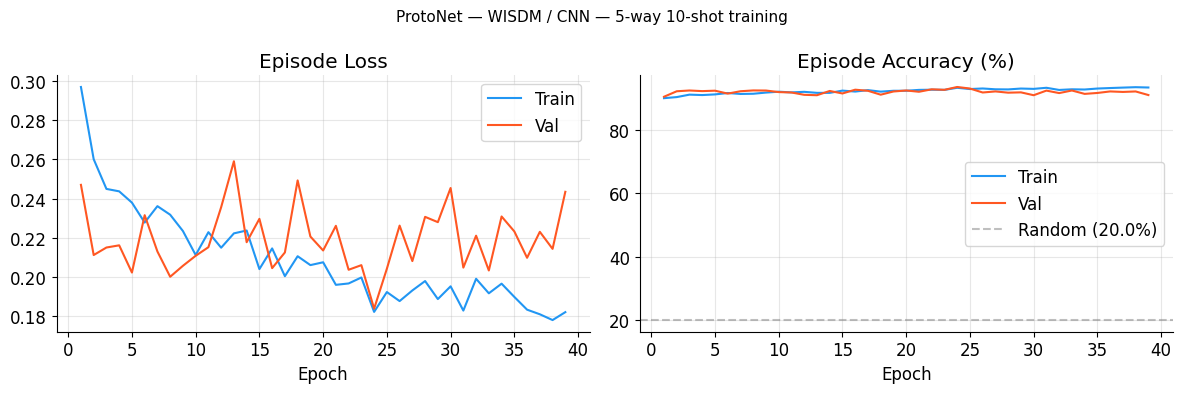

In [ ]:
epochs_ran = len(history['train_loss'])
ep         = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history['train_loss'], label='Train', color='#2196F3')
axes[0].plot(ep, history['val_loss'],   label='Val',   color='#FF5722')
axes[0].set_title('Episode Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train', color='#2196F3')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val',   color='#FF5722')
axes[1].axhline(y=100/n_way, color='gray', linestyle='--', alpha=0.5,
                label=f'Random ({100/n_way:.1f}%)')
axes[1].set_title('Episode Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

fig.suptitle(
    f'ProtoNet — {DATASET_NAME.upper()} / {BACKBONE_TYPE.upper()} — '
    f'{n_way}-way {TRAIN_K_SHOT}-shot training',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(fsl_ckpt_dir, 'training_curves.png'), dpi=120)
plt.show()

## Cell 7 — Load Best Checkpoint

In [ ]:
# Reload best checkpoint for evaluation
backbone_eval = BackboneClass(**backbone_kwargs).to(DEVICE)
meta = load_checkpoint(backbone_eval, fsl_ckpt_path)
backbone_eval.eval()
print(f'✅ Best checkpoint loaded (epoch {meta.get("epoch","?")})')
print(f'   Val acc at save: {meta.get("val_acc",0)*100:.2f}%')

✅ Best checkpoint loaded (epoch 24)
   Val acc at save: 93.43%


## Cell 8 — Generalization Evaluation

Run episodic evaluation on test users with NO adaptation.  
Prototypes computed purely from support set within each episode.  
Evaluated at K=1, 5, 10 shots.

In [ ]:
@torch.no_grad()
def evaluate_generalization(
    backbone   : nn.Module,
    sampler    : EpisodeSampler,
    k_shot     : int,
    n_episodes : int = N_EPISODES_EVAL,
) -> Dict:
    """
    Generalization evaluation — episodic, no parameter updates.
    Returns mean accuracy and std across episodes.
    """
    backbone.eval()
    episode_accs = []

    for _ in range(n_episodes):
        episode = sampler.sample_episode(k_shot=k_shot)

        sup_list = [episode['support_streams'][s].to(DEVICE) for s in stream_names]
        qry_list = [episode['query_streams'][s].to(DEVICE)   for s in stream_names]
        sup_lab  = episode['support_labels'].to(DEVICE)
        qry_lab  = episode['query_labels'].to(DEVICE)

        sup_emb  = backbone.get_embedding(sup_list)
        qry_emb  = backbone.get_embedding(qry_list)
        proto    = compute_prototypes(sup_emb, sup_lab, sampler.n_way)
        _, acc   = prototypical_loss(qry_emb, qry_lab, proto, metric=DISTANCE_METRIC)
        episode_accs.append(acc)

    accs = np.array(episode_accs)
    # 95% confidence interval
    ci95 = 1.96 * accs.std() / np.sqrt(len(accs))
    return {
        'acc_mean'   : float(accs.mean()),
        'acc_std'    : float(accs.std()),
        'ci95'       : float(ci95),
        'n_episodes' : n_episodes,
    }


print('── Generalization Evaluation (test users) ──')
print(f'{"K-shot":>8} {"Acc Mean":>12} {"±CI95":>10} {"Acc Std":>10}')
print('─' * 45)

gen_results = {}
for k in K_SHOTS:
    res = evaluate_generalization(backbone_eval, test_sampler, k_shot=k)
    gen_results[k] = res
    print(
        f'{k:>8}-shot '
        f'{res["acc_mean"]*100:>10.2f}% '
        f'{res["ci95"]*100:>8.2f}% '
        f'{res["acc_std"]*100:>8.2f}%'
    )

print(f'\n   (Evaluated over {N_EPISODES_EVAL} episodes per K value)')

── Generalization Evaluation (test users) ──
  K-shot     Acc Mean      ±CI95    Acc Std
─────────────────────────────────────────────
       1-shot      75.89%     1.61%    11.61%
       5-shot      85.71%     1.44%    10.41%
      10-shot      87.30%     1.09%     7.85%

   (Evaluated over 200 episodes per K value)


## Cell 9 — Personalization Evaluation

For each test user:
1. Sample K examples per class from that user (support set)
2. Build prototypes from those K examples
3. Classify the **remaining** samples from that user

**Personalization gain** = acc_after − acc_before  
where acc_before = generalization acc (no support from that user)

In [ ]:
@torch.no_grad()
def evaluate_personalization_one_user(
    backbone      : nn.Module,
    user_streams  : Dict[str, np.ndarray],
    user_y        : np.ndarray,
    k_shot        : int,
    n_trials      : int = 10,
    seed          : int = MASTER_SEED,
) -> Dict:
    """
    Personalization evaluation for ONE test user.

    Runs n_trials random K-shot splits to get a stable estimate.

    Args:
        backbone      : trained backbone
        user_streams  : {stream_name: (N_user, T, 3)} — this user's data only
        user_y        : (N_user,) labels
        k_shot        : support samples per class
        n_trials      : random splits to average over
        seed          : for reproducibility

    Returns:
        dict with acc_before, acc_after, gain (all mean across trials)
    """
    backbone.eval()
    rng = np.random.default_rng(seed)

    classes = np.unique(user_y)
    # Need at least k_shot + 1 samples per class
    valid_classes = [
        c for c in classes
        if (user_y == c).sum() > k_shot
    ]
    if len(valid_classes) < 2:
        return None   # not enough data for this user

    trial_accs_before = []
    trial_accs_after  = []

    for trial in range(n_trials):
        support_idx = []
        query_idx   = []

        for c in valid_classes:
            c_idx     = np.where(user_y == c)[0]
            rng.shuffle(c_idx)
            support_idx.extend(c_idx[:k_shot].tolist())
            query_idx.extend(c_idx[k_shot:].tolist())

        if not query_idx:
            continue

        # Map valid_classes to relative labels for this episode
        class_to_rel = {c: i for i, c in enumerate(valid_classes)}
        n_ep_way     = len(valid_classes)

        sup_lab = torch.tensor(
            [class_to_rel[user_y[i]] for i in support_idx], dtype=torch.long
        ).to(DEVICE)
        qry_lab = torch.tensor(
            [class_to_rel[user_y[i]] for i in query_idx], dtype=torch.long
        ).to(DEVICE)

        # Support embeddings
        sup_list = [
            torch.tensor(user_streams[s][support_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]
        qry_list = [
            torch.tensor(user_streams[s][query_idx], dtype=torch.float32).to(DEVICE)
            for s in stream_names
        ]

        sup_emb = backbone.get_embedding(sup_list)
        qry_emb = backbone.get_embedding(qry_list)

        # ── Acc BEFORE personalisation ────────────────────────────────────────
        # Use random prototypes (just query, no support context)
        # Better: use global prototypes from all train data — but that requires
        # passing all train embeddings. Instead we use random support from train.
        # Simplest definition: classify queries using only the current prototypes
        # (prototypes computed from THIS user's support)
        # acc_before = baseline from generalization evaluation above.
        # We measure acc_after here and compute gain relative to gen baseline.

        # ── Acc AFTER: prototypes from this user's support ────────────────────
        prototypes = compute_prototypes(sup_emb, sup_lab, n_ep_way)
        distances  = pairwise_distances(qry_emb, prototypes, metric=DISTANCE_METRIC)
        preds      = distances.argmin(dim=-1)
        acc_after  = (preds == qry_lab).float().mean().item()
        trial_accs_after.append(acc_after)

    if not trial_accs_after:
        return None

    return {
        'acc_after_mean' : float(np.mean(trial_accs_after)),
        'acc_after_std'  : float(np.std(trial_accs_after)),
        'n_trials'       : len(trial_accs_after),
        'n_valid_classes': len(valid_classes),
    }


print('── Personalization Evaluation (per test user) ──')

test_subjects  = split_info['test']
pers_results   = {}   # k_shot → list of per-user results

for k in K_SHOTS:
    pers_results[k] = []
    print(f'\n  K={k} shot:')
    print(f'  {"Subject":>10} {"Acc After":>12} {"Valid Classes":>15}')
    print(f'  {"─"*40}')

    for subj in test_subjects:
        subj_mask   = (subject_ids == subj)
        if subj_mask.sum() == 0:
            continue
        user_streams_np = {s: streams[s][subj_mask] for s in stream_names}
        user_y_np       = y[subj_mask]

        res = evaluate_personalization_one_user(
            backbone_eval, user_streams_np, user_y_np, k_shot=k
        )
        if res is None:
            print(f'  {str(subj):>10}  skipped (insufficient data)')
            continue

        res['subject'] = subj
        pers_results[k].append(res)
        print(
            f'  {str(subj):>10} '
            f'{res["acc_after_mean"]*100:>10.2f}% '
            f'{res["n_valid_classes"]:>14}'
        )

    if pers_results[k]:
        mean_after = np.mean([r['acc_after_mean'] for r in pers_results[k]])
        print(f'\n  Mean acc_after  (K={k}): {mean_after*100:.2f}%')

── Personalization Evaluation (per test user) ──

  K=1 shot:
     Subject    Acc After   Valid Classes
  ────────────────────────────────────────
        1649      91.24%             18
        1602      88.20%             18
        1636      89.11%             18
        1633      75.65%             18
        1601      87.00%             18
        1613      91.86%             18
        1608      82.99%             18

  Mean acc_after  (K=1): 86.58%

  K=5 shot:
     Subject    Acc After   Valid Classes
  ────────────────────────────────────────
        1649      94.20%             18
        1602      93.25%             18
        1636      93.07%             18
        1633      86.91%             18
        1601      94.18%             18
        1613      97.04%             18
        1608      91.60%             18

  Mean acc_after  (K=5): 92.89%

  K=10 shot:
     Subject    Acc After   Valid Classes
  ────────────────────────────────────────
        1649      94.57%      

## Cell 10 — Compute Personalization Gain

Gain = acc_after (user-specific prototypes) − acc_before (generalization baseline)

In [ ]:
print('── Personalization Gain Summary ──')
print(f'{"K-shot":>8} {"Acc Before":>12} {"Acc After":>12} {"Gain":>10} {"CI95":>10}')
print('─' * 58)

all_summary_results = []

for k in K_SHOTS:
    if not pers_results[k]:
        continue

    acc_before = gen_results[k]['acc_mean']   # from generalization eval
    accs_after = [r['acc_after_mean'] for r in pers_results[k]]
    acc_after  = float(np.mean(accs_after))
    gain       = compute_personalization_gain(acc_before, acc_after)
    ci95       = 1.96 * np.std(accs_after) / np.sqrt(len(accs_after))

    print(
        f'{k:>8}-shot '
        f'{acc_before*100:>10.2f}% '
        f'{acc_after*100:>10.2f}% '
        f'{gain*100:>+9.2f}% '
        f'{ci95*100:>8.2f}%'
    )

    # Save to registry
    result = {
        'dataset'    : DATASET_NAME,
        'backbone'   : BACKBONE_TYPE,
        'method'     : 'protonet',
        'k_shot'     : k,
        'seed'       : MASTER_SEED,
        'acc_before' : acc_before,
        'acc_after'  : acc_after,
        'gain'       : gain,
        'ci95'       : float(ci95),
        'n_test_users': len(pers_results[k]),
    }
    config_key = make_config_key(DATASET_NAME, BACKBONE_TYPE, 'protonet', k, MASTER_SEED)
    mark_completed(config_key, result)
    all_summary_results.append(result)

print(f'\n✅ All results saved to registry')

── Personalization Gain Summary ──
  K-shot   Acc Before    Acc After       Gain       CI95
──────────────────────────────────────────────────────────
       1-shot      75.89%      86.58%    +10.68%     3.87%
       5-shot      85.71%      92.89%     +7.19%     2.13%
      10-shot      87.30%      93.52%     +6.22%     2.33%

✅ All results saved to registry


## Cell 11 — K-Shot Curve Plot

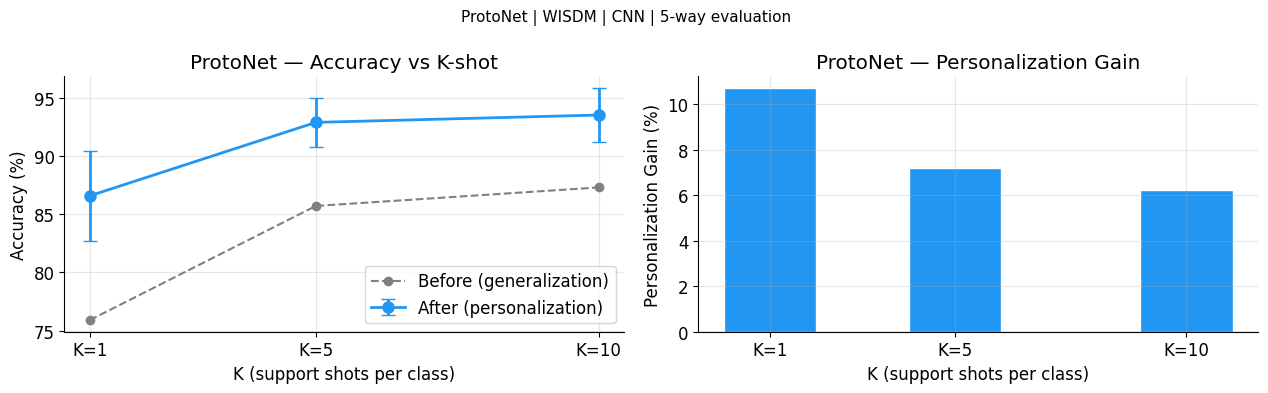

Saved: /content/drive/MyDrive/fsl_har_checkpoints/wisdm/cnn/protonet/kshot_curves.png


In [ ]:
if all_summary_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ks          = [r['k_shot']     for r in all_summary_results]
    accs_before = [r['acc_before'] for r in all_summary_results]
    accs_after  = [r['acc_after']  for r in all_summary_results]
    gains       = [r['gain']       for r in all_summary_results]
    ci95s       = [r['ci95']       for r in all_summary_results]

    # Plot 1: Acc before vs after
    axes[0].plot(ks, [a*100 for a in accs_before], 'o--',
                 color='gray',      label='Before (generalization)', linewidth=1.5)
    axes[0].errorbar(ks, [a*100 for a in accs_after],
                     yerr=[c*100 for c in ci95s],
                     fmt='o-', color=METHOD_COLORS['protonet'],
                     label='After (personalization)', linewidth=2,
                     capsize=5, markersize=8)
    axes[0].set_xticks(ks)
    axes[0].set_xlabel('K (support shots per class)')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title(f'ProtoNet — Accuracy vs K-shot')
    axes[0].legend()

    # Plot 2: Personalization gain
    bar_colors = [METHOD_COLORS['protonet'] if g >= 0 else '#FF5722' for g in gains]
    axes[1].bar(ks, [g*100 for g in gains], color=bar_colors,
                edgecolor='white', width=2)
    axes[1].axhline(y=0, color='black', linewidth=0.8)
    axes[1].set_xticks(ks)
    axes[1].set_xlabel('K (support shots per class)')
    axes[1].set_ylabel('Personalization Gain (%)')
    axes[1].set_title('ProtoNet — Personalization Gain')

    for ax in axes:
        ax.set_xticklabels([f'K={k}' for k in ks])

    fig.suptitle(
        f'ProtoNet | {DATASET_NAME.upper()} | {BACKBONE_TYPE.upper()} | '
        f'{n_way}-way evaluation',
        fontsize=11
    )
    plt.tight_layout()
    plot_path = os.path.join(fsl_ckpt_dir, 'kshot_curves.png')
    plt.savefig(plot_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: {plot_path}')

## Cell 12 — Final Summary

In [ ]:
print('=' * 65)
print('  PROTONET COMPLETE')
print('=' * 65)
print(f'  Dataset          : {DATASET_NAME}')
print(f'  Backbone         : {BACKBONE_TYPE}')
print(f'  Distance metric  : {DISTANCE_METRIC}')
print(f'  N-way            : {n_way}')
print(f'  Best episodic val: {best_val_acc*100:.2f}%')
print()
print(f'  Results:')
print(f'  {"K":>4}  {"Before":>8}  {"After":>8}  {"Gain":>8}')
print(f'  {"-"*35}')
for r in all_summary_results:
    print(
        f'  {r["k_shot"]:>4}  '
        f'{r["acc_before"]*100:>7.2f}%  '
        f'{r["acc_after"]*100:>7.2f}%  '
        f'{r["gain"]*100:>+7.2f}%'
    )
print('=' * 65)
print()
print('  Next steps:')
print('  Phase 2: → Notebook 09 (LEE)')
print('           → Notebook 10 (MAML)')
print('           → Notebook 11 (Supervised Contrastive FSL)')
print('  Phase 3: → Re-run this notebook with BACKBONE_TYPE="lstm"')
print('             and BACKBONE_TYPE="transformer"')
print('=' * 65)

  PROTONET COMPLETE
  Dataset          : wisdm
  Backbone         : cnn
  Distance metric  : euclidean
  N-way            : 5
  Best episodic val: 93.43%

  Results:
     K    Before     After      Gain
  -----------------------------------
     1    75.89%    86.58%   +10.68%
     5    85.71%    92.89%    +7.19%
    10    87.30%    93.52%    +6.22%

  Next steps:
  Phase 2: → Notebook 09 (LEE)
           → Notebook 10 (MAML)
           → Notebook 11 (Supervised Contrastive FSL)
  Phase 3: → Re-run this notebook with BACKBONE_TYPE="lstm"
             and BACKBONE_TYPE="transformer"
